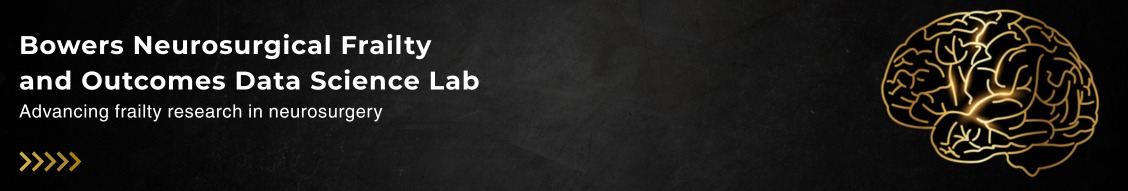

## About the Author

##### I'm Omar M. M. Mansoor, a member of the Bowers Neurosurgical Frailty and Outcomes Data Science Lab. This project is meant to serve as a quick, short guide for conducting statistics and visualization in Python as the 1st of 3. 

##### While not fully comprehensive nor detailed, it lays down the basic fundamentals of analysis and visualization, some basic API calls and navigating commonly used functions.

##### It is to be noted that I was only a beginner with Python and Data Science last July. But with the unwavering support and mentorship by my mentor, Dr. Christian Bowers, I was able to develop my skills to an advanced level. I will forever be thankful and indebted to my mentor.

##### For any questions, feel free to reach out via email at omarmohmansoor@gmail.com
##### You can connect with me and follow my works through any of the social media pages below.
##### LinkedIn: https://www.linkedin.com/in/omarmohmansoor/
##### Twitter: https://x.com/OmarMohMansoor 
##### GitHub: https://github.com/omarmohmansoor

#### -------------------------------------------------------------------------------------------------------------------------------------------------

## Prerequisites & Packages

##### Packages that will be used: Pandas, NumPy, SciPy, Seaborn, and Matplotlib. If you don't have them installed, open your kernell and write the following command:

##### !pip install pandas numpy seaborn matplotlib scipy

In [1]:
# First we will import the packages, we typically import the package with a short-hand notation to simplify API calls.

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt # matplotlib.pyplot is a different call from only matplotlib. For figures you want to call .pyplot
from scipy import stats # SciPy uses a 'from' command, you can actually call the specific test from SciPy, example: from 'scipy.stats import shapirowilk'. 
                        # However, for simplicity's sake and to just import it once and for all in a project, import stats from scipy. Each test will then be a stats.testname(x,y)

## Importing Data and Utilization of DataFrames

##### When working, you'll typically import data either from an excel (.xlsx) or csv (.csv) file. Pandas lets you import them into a DataFrame. I have uplaoded a p1 sample dataset that we will use throughout the study. 

##### Normally, you'll import excel (.xlsx) files, you can specify the sheet name as well. Important note: if you are using windows make sure that you either use / or \\ when placing the path of the data file, that is if the data file is not saved in the same folder as the python/jupyter notebooks file that you are using. Mac users should check the web for file paths guidelines.

##### Note, the data file associated with this guide was generated randomly and does not represent any actual patient data obtained from any study or database.

In [2]:
# we want to create a variable called df (short for dataframe), it doesn't have to be df it can be df_a, dfbb, or anything else you'd want it to be.

df = pd.read_csv('bowers_datascience_dataset.csv')

# if you are working with excel, replace csv with excel and the .csv at the end with .xlsx; pandas will read the 1st sheet as default, if you want to specify a sheet in particular with excel, after you do the initial file import, write sheet_name = 'sheet_name'.

### Understanding the Data Set

In [7]:
df.head(5) # shows the first 5 rows

,patient_id,age,gender,bmi,procedure,asa_class,mfi5,frailty_category,kps_score,charlson_index,...,diabetes,chf,copd,prior_stroke,op_time_min,ebl_ml,any_complication,los_days,discharge_disposition,readmit_30d
0,NS001,62,Male,27.4,Cervical Fusion,4,3,Frail,60,5,...,1,1,0,0,98,320,0,11.2,SNF/Rehab,0
1,NS002,88,Male,35.7,Lumbar Fusion,4,4,Frail,60,4,...,0,1,0,0,245,580,1,14.0,SNF/Rehab,1
2,NS003,67,Male,22.2,Cervical Fusion,2,2,Pre-Frail,60,3,...,1,0,0,0,202,560,1,9.8,SNF/Rehab,1
3,NS004,81,Female,36.1,Cervical Fusion,4,4,Frail,50,3,...,0,0,1,0,181,390,1,11.0,SNF/Rehab,1
4,NS005,61,Female,26.4,Cervical Fusion,4,2,Pre-Frail,60,2,...,1,0,0,0,156,490,1,14.0,Home with Services,0


In [8]:
df.columns # gives us the column names

Index(['patient_id', 'age', 'gender', 'bmi', 'procedure', 'asa_class', 'mfi5',
       'frailty_category', 'kps_score', 'charlson_index', 'albumin_gdl',
       'sodium_meql', 'preop_hgb_gdl', 'hypertension', 'diabetes', 'chf',
       'copd', 'prior_stroke', 'op_time_min', 'ebl_ml', 'any_complication',
       'los_days', 'discharge_disposition', 'readmit_30d'],
      dtype='object')

In [9]:
df.describe() # describe each column of the dataset

,age,bmi,asa_class,mfi5,kps_score,charlson_index,albumin_gdl,sodium_meql,preop_hgb_gdl,hypertension,diabetes,chf,copd,prior_stroke,op_time_min,ebl_ml,any_complication,los_days,readmit_30d
count,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000
mean,63.815789,28.671053,3.289474,2.368421,65.263158,2.973684,3.689474,139.107895,12.750000,0.578947,0.473684,0.210526,0.342105,0.052632,170.578947,422.105263,0.473684,10.402632,0.421053
std,11.219807,5.567906,0.835299,1.148937,14.655843,2.046577,0.321138,3.990420,1.155656,0.500355,0.506009,0.413155,0.480783,0.226294,74.985271,153.308696,0.506009,2.541705,0.500355
min,33.000000,17.000000,1.000000,0.000000,40.000000,0.000000,3.100000,131.800000,10.700000,0.000000,0.000000,0.000000,0.000000,0.000000,51.000000,130.000000,0.000000,5.700000,0.000000
25%,57.500000,25.025000,3.000000,2.000000,52.500000,2.000000,3.500000,135.100000,11.900000,0.000000,0.000000,0.000000,0.000000,0.000000,114.250000,320.000000,0.000000,8.625000,0.000000
50%,63.500000,29.000000,3.500000,2.000000,70.000000,3.000000,3.600000,139.800000,12.850000,1.000000,0.000000,0.000000,0.000000,0.000000,169.500000,395.000000,0.000000,10.250000,0.000000
75%,69.750000,32.975000,4.000000,3.000000,70.000000,4.000000,3.875000,142.025000,13.450000,1.000000,1.000000,0.000000,1.000000,0.000000,220.000000,507.500000,1.000000,11.950000,1.000000
max,88.000000,37.200000,4.000000,4.000000,90.000000,7.000000,4.400000,146.100000,14.800000,1.000000,1.000000,1.000000,1.000000,1.000000,330.000000,790.000000,1.000000,15.400000,1.000000


## Descriptive Statistics

In [22]:
desc_gender = df.groupby('gender')[['age', 'bmi', 'kps_score', 'albumin_gdl', 'sodium_meql', 'preop_hgb_gdl', 'op_time_min', 'ebl_ml', 'los_days']].agg(['count', 'mean','median','std','min','max', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)
]).round(2)

print(desc_gender) # In essence, we grouped patients by gender for all categories that we wanted to descriptive statistics for. Same can be done by procedure. The round (2) is to round to 2 decimal places.

         age                                                      bmi         \
       count   mean median    std min max <lambda_0> <lambda_1> count   mean   
gender                                                                         
Female    18  64.89   63.5  10.74  41  88      59.50      70.50    18  28.31   
Male      20  62.85   63.0  11.82  33  88      56.75      69.25    20  28.99   

        ...     ebl_ml            los_days                                 \
        ... <lambda_0> <lambda_1>    count   mean median   std  min   max   
gender  ...                                                                 
Female  ...      267.5      487.5       18  10.06  10.20  2.72  5.7  15.4   
Male    ...      347.5      530.0       20  10.72  10.25  2.40  6.3  14.9   

                              
       <lambda_0> <lambda_1>  
gender                        
Female       8.30      11.48  
Male         9.55      12.82  

[2 rows x 72 columns]


In [23]:
desc_proc = df.groupby('procedure')[['age', 'bmi', 'kps_score', 'albumin_gdl', 'sodium_meql', 'preop_hgb_gdl', 'op_time_min', 'ebl_ml', 'los_days']].agg(['count', 'mean','median','std','min','max', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)
]).round(2)

print(desc_proc)

                       age                                                     \
                     count   mean median    std min max <lambda_0> <lambda_1>   
procedure                                                                       
Cervical Fusion         13  68.46   67.0   8.03  61  88       63.0       70.0   
Craniotomy               9  60.89   60.0  10.23  45  74       54.0       72.0   
Lumbar Fusion            6  63.17   59.0  16.59  41  88       56.0       72.5   
Spinal Decompression     6  61.00   66.0  14.91  33  75       59.0       68.5   
VP Shunt                 4  60.50   61.0   5.97  53  67       57.5       64.0   

                       bmi         ...     ebl_ml            los_days         \
                     count   mean  ... <lambda_0> <lambda_1>    count   mean   
procedure                          ...                                         
Cervical Fusion         13  30.49  ...      360.0      500.0       13  10.49   
Craniotomy               9  28.

In [ ]:
# Now, we want to save the results into an excel file.
# This way, we can save all the descriptives below one another on the same sheet to keep things concise.

with pd.ExcelWriter('descriptives.xlsx', engine='xlsxwriter') as writer:
    worksheet = writer.book.add_worksheet('Descriptives')
    worksheet.write(0, 0, 'By Gender')
    desc_gender.to_excel(writer, sheet_name='Descriptives', startrow=0)
    gap_row = len(desc_gender) + 4
    worksheet.write(gap_row, 0, 'By Procedure')
    desc_proc.to_excel(writer, sheet_name='Descriptives', startrow=gap_row + 1)

# Result sheet shown below.

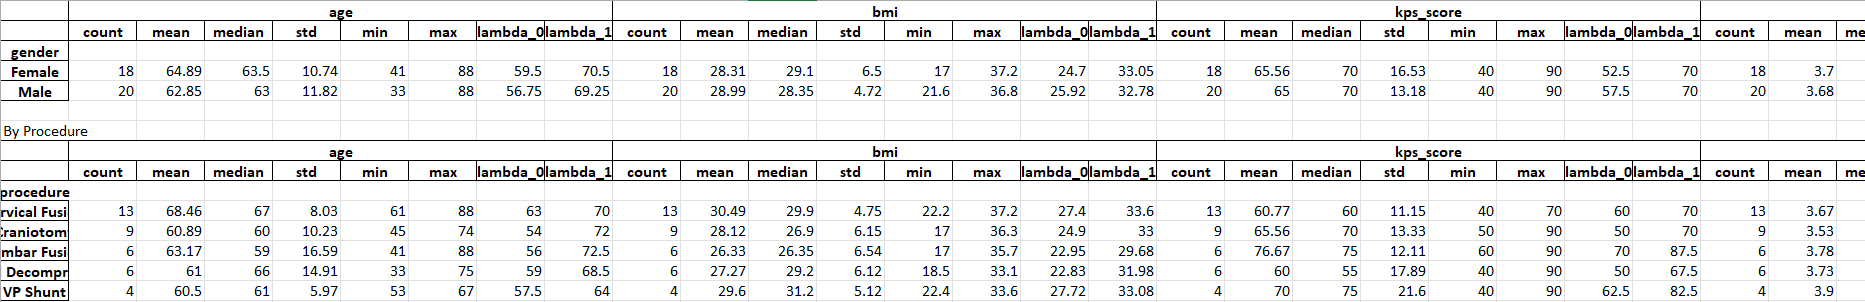

## Assessing Normality of the Data

In [ ]:
# We can specify the column that we want to assess the normality for by filtering for the specific column and running kurtosis, skewness, shapiro-wilk

sdmql = df['sodium_meql']

sdmql_kurt = stats.kurtosis(sdmql)
sdmql_skew = stats.skew(sdmql)
sdmql_shap = stats.shapiro(sdmql)

print(sdmql_kurt)
print(sdmql_skew)
print(sdmql_shap) # this will show us the results for each test below the cell.

# However, this is impractical. Typically we have multiple variables that we want to test their normality, doing them one by one is inefficient.

-1.0991230066678404
-0.052293528003621505
ShapiroResult(statistic=0.9538538703451719, pvalue=0.11932681366374193)


In [43]:
# We can do a loop that allows us to do normality for multiple variables.

nor_var = ['bmi', 'albumin_gdl', 'sodium_meql', 'preop_hgb_gdl', 'op_time_min', 'ebl_ml'] # we specify the variables we want to test

results = []
for col in nor_var:
    s = df[col]
    shap = stats.shapiro(s)
    results.append({
        'Variable': col,
        'Kurtosis': round(stats.kurtosis(s), 4), # we used the round argument to round the number of decimal places to 4; you don't have to do it.
        'Skewness': round(stats.skew(s), 4),
        'Shapiro-Wilk W': round(shap.statistic, 4), # We used shap since we defined what is shap above; this one is for the cofficient of shapiro-wilk
        'Shapiro-Wilk p': round(shap.pvalue, 4), # Shapiro-wilk p value
        'Normal (p>0.05)' : 'Yes' if shap.pvalue > 0.05 else 'Skewed' # This argument gives us what we want to know from Shapiro-Wilk: is the data normally distributed or skewed based on p-value being > 0.05 for normal and < 0.05 for skewed.
    })

normality_tests = pd.DataFrame(results)
print(normality_tests) # This will print the results below the cell or in the kernell

# If we want to save to excel

normality_tests.to_excel('normality_tests.xlsx', index=False)

        Variable  Kurtosis  Skewness  Shapiro-Wilk W  Shapiro-Wilk p  \
0            bmi   -0.6776   -0.3670          0.9595          0.1825   
1    albumin_gdl   -0.2380    0.5231          0.9610          0.2041   
2    sodium_meql   -1.0991   -0.0523          0.9539          0.1193   
3  preop_hgb_gdl   -0.9315   -0.0359          0.9688          0.3615   
4    op_time_min   -0.6533    0.3782          0.9691          0.3692   
5         ebl_ml   -0.4516    0.2368          0.9843          0.8596   

  Normal (p>0.05)  
0             Yes  
1             Yes  
2             Yes  
3             Yes  
4             Yes  
5             Yes  


Text(0, 0.5, 'Count')

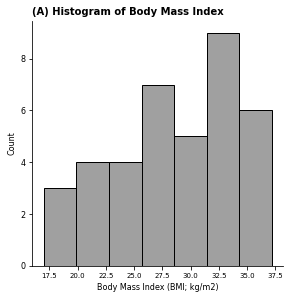

In [ ]:
# Typically, we can't only rely on Shapiro-wilk, kurtosis and skewness to assess normality of the data. We often want to also how the data looks when visualized. Most commonly a histogram is used. Below is the code for constructing a histogram using the standards specified in the Figures Guide file.

plt.figure(figsize=(4.5,4.5)) # Inches, width x height

ax = sns.histplot(df, x='bmi', color='gray') # Calling the figure
# we first introduce the dataframe used, the x-variable (distriubtional plots only take either an x or y variable), color/palette if we want a specific color.
# By default, different types of distribution plots will show a different measurement method on the y-axis. You can specify those via referring to the API calls for histplot on the official seaborn API documentation.

ax.set_title('(A) Histogram of Body Mass Index', fontsize=10, weight='bold', loc='left')
ax.tick_params(axis='x', labelsize=7, bottom=True, direction='out')
ax.tick_params(axis='y', labelsize=8, left=True, direction='out')
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlabel('Body Mass Index (BMI; kg/m2)', fontsize=8)
ax.set_ylabel('Count', fontsize=8)

plt.tight_layout() # Removes any additional white spaces.

plt.savefig('histplot_of_bmi.svg', dpi=1200, bbox_inches='tight')
# Make sure you specify the type of the file that you want to save the figure in. Typically we use svg especially if you want to create subplots with softwares like Adobe Illustrator or Inksacpe. DPI between 800 - 1200 to make sure it is not pixelated. Bbox_inches serves similar to plt.tight_layout()

##### Say the data was skewed, how would it look like in a histplot?

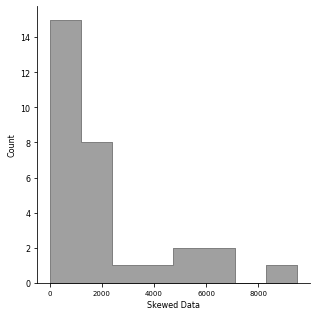

In [ ]:
sk = [0, 0, 0, 1, 2, 3, 4, 1, 2, 4, 5, 1, 1000, 1200, 1400, 1500, 2000, 2500, 4000, 5000, 5050, 6500, 7000, 9500, 1050, 1100, 1200, 1400, 1500, 1550]

plt.figure(figsize=(4.5,4.5))

ax = sns.histplot(x=sk, color='gray', element='step') # added the element function as a change of style

ax.tick_params(axis='x', labelsize=7, bottom=True, direction='out')
ax.tick_params(axis='y', labelsize=8, left=True, direction='out')
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlabel('Skewed Data', fontsize=8)
ax.set_ylabel('Count', fontsize=8)
plt.tight_layout()

##### In situations like this, we typically would be inclined to do a log-transformation of the data especially if we want to use a test like pearson correlation. 

**Note: Depending on the nature of the variable and what it represents, at times even log-transformation cannot reduce the heavy skewness present in a variable. Additionally, if the variable is something like publications count, that is not something natural or normal, like BMI or height where we can assume central limit theorem.** 

C:\Users\JC\AppData\Local\Temp\ipykernel_12716\13301357.py:1: RuntimeWarning: divide by zero encountered in log
  log_sk = np.log(sk)


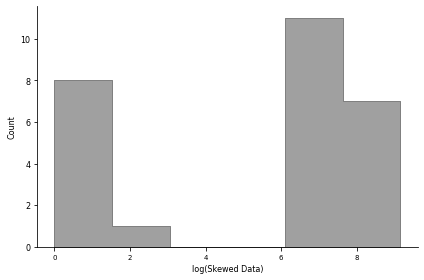

In [57]:
log_sk = np.log(sk)

ax = sns.histplot(x=log_sk, color='gray', element='step') # added the element function as a change of style

ax.tick_params(axis='x', labelsize=7, bottom=True, direction='out')
ax.tick_params(axis='y', labelsize=8, left=True, direction='out')
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlabel('log(Skewed Data)', fontsize=8)
ax.set_ylabel('Count', fontsize=8)
plt.tight_layout()

In [ ]:
## Now we check the shapiro wilk value for the log-transformed data

stats.shapiro(log_sk)

## Goes without saying that I randomly generated the values above. This will be more practical with a real set, but the idea is there.

ShapiroResult(statistic=nan, pvalue=1.0)

##### Feel free to further explore the different types of distributional plots and their API calls via seaborn's API documentation (https://seaborn.pydata.org/api.html)

## Parametric Tests

##### Considering that the dataset we have is normally distributed, I'll demonstate parametric tests. Although the same principles shown below for running the tests and visualizing the data are identical to non-parametric; albeit, just different API calls. The only difference will be visualizing Spearman rho, where you need to visualize the ranked data not the raw one, unlike Pearson.

In [67]:
### Say we want to do an independent t-test to compare length of stay between males and females. We first want to specify the groups, run the test, visualize it and plot the star bars.

male = df[df['gender'] == 'Male']['los_days']
female = df[df['gender'] == 'Female']['los_days']

los_ttest = stat, p = stats.ttest_ind(male, female)

print(los_ttest)

TtestResult(statistic=0.7945810717670413, pvalue=0.4320644902139662, df=36.0)


In [89]:
from statannotations.Annotator import Annotator # we will need this package to draw the star bars. If you don't have it installed, do 'pip install statannotations' in the kernel

In [73]:
# We also want to specify the colors for the hue argument below.

palette_box = {
    'Cervical Fusion': '#be1818',
    'Lumbar Fusion': '#f58220',
    'Craniotomy': '#0070a8',
    'Spinal Decompression': '#00a69d',
    'VP Shunt': '#01324b'
}

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Male vs. Female: t-test independent samples, P_val:4.321e-01 t=7.946e-01


(<Axes: ylabel='Length of Stay (Days)'>,
 [<statannotations.Annotation.Annotation at 0x2ba297a35f0>])

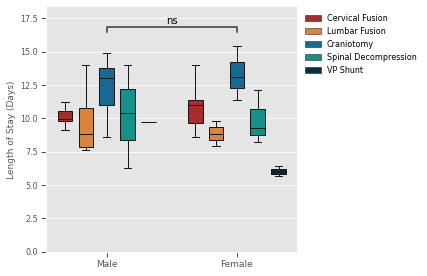

In [ ]:
sns.set_context('paper')
plt.style.use('ggplot') # did this for a bit of change and to demonstrate that there are multiple styles that you can use.

plt.figure(figsize=(4.5,4.5))

ax = sns.boxplot(df, x='gender', y='los_days', hue='procedure', gap=0.3, palette=palette_box)
ax.set_ylim(0,18) # typically you don't want to use this argument. However, since the default plot showed the y axis from 4 to 15, I want to show the true sacle from 0 to 18, to give the plot some breadth
ax.legend(fontsize=8, bbox_to_anchor=[1,1], frameon=False)
ax.tick_params(axis='x', labelsize=9, bottom=True, direction='out')
ax.tick_params(axis='y', labelsize=8, left=True, direction='out')
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlabel('', fontsize=8)
ax.set_ylabel('Length of Stay (Days)', fontsize=9)

pairs = [('Male', 'Female')] # We need this argument to visualize the star bars

annotator = Annotator(ax, pairs, data=df, x='gender', y='los_days')
annotator.configure(test='t-test_ind', text_format='star', loc='inside')
annotator.apply_and_annotate() # We can see that the star bars is for t-test independent shows NS- Non-Significant. This is another way of showing p-values while also demonstrating the data.

##### In terms of code, the same principles apply through and through. Whether it's Mann-Whitney, ANOVA, Kruskal-Wallis, Friedman or Repeated Measures ANOVA. The code structure is the exact same, the only part that differs is the number of columns/variables for each test and the API call made.

In [ ]:
## We'll do a pearson correlation coefficient as our last example.

pearson_results = stats.pearsonr(df['los_days'], df['ebl_ml'])

print(pearson_results)

PearsonRResult(statistic=0.5453596847631265, pvalue=0.00039883571197556146)


Text(6, 800, 'r=0.55, p< .001')

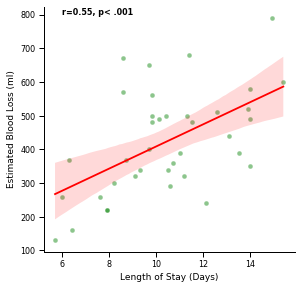

In [5]:
# The results aren't too bad. Let's visualize it now.

sns.set_context('paper')

plt.figure(figsize=(4.5,4.5))

ax = sns.scatterplot(df, x='los_days', y='ebl_ml', color='green', alpha=0.45) # We want to plot the scatterplots to be more in the background, so we use the alpa argument. Considering that the plot itself is gray, we'll use green for the scatter points.
ax = sns.regplot(df, x='los_days', y='ebl_ml', color='red', ci=95, scatter=False) # we want to disable the scatter points made by the regplot function since they will overlay the ones from the scatterplot and cause the figure to be too crowded.
ax.tick_params(axis='x', labelsize=8, bottom=True, direction='out')
ax.tick_params(axis='y', labelsize=8, left=True, direction='out')
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlabel('Length of Stay (Days)', fontsize=9)
ax.set_ylabel('Estimated Blood Loss (ml)', fontsize=9)
ax.text(s='r=0.55, p< .001', x=6, y=800, fontsize=8, weight='bold')

##### **Note** Do not use plt.show() function before plt.save, it will save the figure as an empty white screen. When plt.show() is passed, it will clean the figure from the memory aftewards, so you should ideally leave plt.show() as the last function. Also, if you're using Jupyter Notebooks you typically don't need to call the plt.show() function as long as you don't pass the '%matplotlib inline' command when calling the packages; the plots will be shown below the command cell by default.

## Final Notes

##### This part 1 is only a brief introduction into the layout of the syntax and overall structure. Part 2 will dive deeper into visualization methods, and some visualization theory. Part 3 remains undecided for now.